## Preprocessing & EDA — Hate Speech Multilabel
Notebook ini:
1. Load data asli (`/kaggle/input/datasethatespeechmultilabel/re_dataset.csv`)
2. EDA lengkap (statistik, distribusi label, panjang teks, top words)
3. Cleaning teks (lowercase, remove URL/mentions/punctuation/angka, normalisasi alay)
4. Tampilkan contoh **before / after** (random n)
5. Stratified multilabel split (MultilabelStratifiedShuffleSplit)
6. Simpan outputs: `clean_data.csv`, `train_df.csv`, `test_df.csv`

In [3]:
# === Imports & config ===
import os
import random
import re
import string
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Multilabel stratified split
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

# Visual settings
plt.rcParams['figure.figsize'] = (10,5)
sns.set(style="whitegrid")

RAW_CSV = "/kaggle/input/datasethatespeechmultilabel/re_dataset.csv"
ALAY_CSV = "/kaggle/input/datasethatespeechmultilabel/new_kamusalay.csv"

OUT_DIR = "preprocessed_output"
os.makedirs(OUT_DIR, exist_ok=True)

RANDOMIZE_SEED = True 
SEED = 42 if not RANDOMIZE_SEED else random.randint(0, 999999)
print("RANDOMIZE_SEED:", RANDOMIZE_SEED, " | SEED:", SEED)

np.random.seed(SEED)
random.seed(SEED)

RANDOMIZE_SEED: True  | SEED: 925471


## 1. Load Dataset & Eksplorasi Awal

Memuat dataset asli dan melihat gambaran umum: ukuran data, kolom, tipe data, serta missing values.


In [4]:
# === Load data ===
df_raw = pd.read_csv(RAW_CSV, encoding='latin-1')
df_raw = df_raw.drop(columns=['HS','Abusive','HS_Other','HS_Weak','HS_Moderate','HS_Strong'])
print("Raw shape:", df_raw.shape)
display(df_raw.head(6))

# Quick data info
print("\nKolom dataset:", df_raw.columns.tolist())
print("\nTipe data:")
display(df_raw.dtypes)
print("\nJumlah missing per kolom:")
print(df_raw.isna().sum())


Raw shape: (13169, 7)


,Tweet,HS_Individual,HS_Group,HS_Religion,HS_Race,HS_Physical,HS_Gender
0,- disaat semua cowok berusaha melacak perhatia...,1,0,0,0,0,0
1,RT USER: USER siapa yang telat ngasih tau elu?...,0,0,0,0,0,0
2,"41. Kadang aku berfikir, kenapa aku tetap perc...",0,0,0,0,0,0
3,USER USER AKU ITU AKU\n\nKU TAU MATAMU SIPIT T...,0,0,0,0,0,0
4,USER USER Kaum cebong kapir udah keliatan dong...,0,1,1,0,0,0
5,USER Ya bani taplak dkk \xf0\x9f\x98\x84\xf0\x...,0,1,0,0,0,0



Kolom dataset: ['Tweet', 'HS_Individual', 'HS_Group', 'HS_Religion', 'HS_Race', 'HS_Physical', 'HS_Gender']

Tipe data:


Tweet            object
HS_Individual     int64
HS_Group          int64
HS_Religion       int64
HS_Race           int64
HS_Physical       int64
HS_Gender         int64
dtype: object


Jumlah missing per kolom:
Tweet            0
HS_Individual    0
HS_Group         0
HS_Religion      0
HS_Race          0
HS_Physical      0
HS_Gender        0
dtype: int64


In [5]:
label_cols = [c for c in df_raw.columns if c.startswith("HS_")]
print("Label columns detected:", label_cols)
y = df_raw[label_cols].copy()
print("\nUkuran dataset:", len(df_raw))
print("\nProporsi positif per label (sebelum cleaning):")
display(y.mean().sort_values(ascending=False))


Label columns detected: ['HS_Individual', 'HS_Group', 'HS_Religion', 'HS_Race', 'HS_Physical', 'HS_Gender']

Ukuran dataset: 13169

Proporsi positif per label (sebelum cleaning):


HS_Individual    0.271471
HS_Group         0.150809
HS_Religion      0.060217
HS_Race          0.042980
HS_Physical      0.024527
HS_Gender        0.023236
dtype: float64

Menggunakan kolom teks: Tweet

Panjang teks (chars):


,count,mean,std,min,25%,50%,75%,max
_text_len,13169.0,114.202749,69.07562,4.0,59.0,100.0,152.0,561.0


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


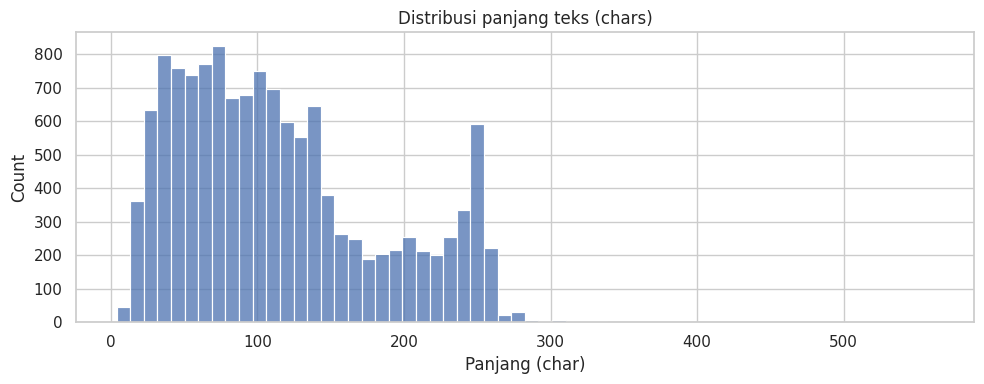


Contoh raw texts (random 5):


['USER aku katakan anjing kpd ahmad dani, boleh....aku katakan babi kpd ahmad dhani, boleh...',
 "USER USER ASTAGA BOLOT BANGET DIA'",
 "USER Gua emg lagi diving sarap'",
 "Mendebat istilah Islam Nusantara nanti saya bisa dituding pro khilafah, HTI, atau ISIS. Sebaliknya mendukung Islam Nusantara saya bisa dicap antek-antek JIL, pro Yahudi, bid'ah dan sesat. Ya sudahlah saya cukup deklarasi bahwa saya orang Indonesia dan be",
 "USER Pengen eek di kamar mandi tapi ada kecoa ih aq takut \\xf0\\x9f\\x98\\xad\\xf0\\x9f\\x98\\xad\\xf0\\x9f\\x98\\xad\\xf0\\x9f\\x98\\xad\\xf0\\x9f\\x98\\xad\\xf0\\x9f\\x98\\xad\\xf0\\x9f\\x98\\xad\\xf0\\x9f\\x98\\xad\\xf0\\x9f\\x98\\xad\\xf0\\x9f\\x98\\xad\\xf0\\x9f\\x98\\xad'"]

In [6]:
text_col_candidates = [c for c in df_raw.columns if c.lower() in ("tweet","text","tweet_text","content")]
if len(text_col_candidates)==0:
    text_col = df_raw.select_dtypes(include='object').columns[0]
else:
    text_col = text_col_candidates[0]
print("Menggunakan kolom teks:", text_col)

df_raw['_text_len'] = df_raw[text_col].fillna("").astype(str).apply(len)
print("\nPanjang teks (chars):")
display(df_raw['_text_len'].describe().to_frame().T)

plt.figure(figsize=(10,4))
sns.histplot(df_raw['_text_len'], bins=60)
plt.title("Distribusi panjang teks (chars)")
plt.xlabel("Panjang (char)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("\nContoh raw texts (random 5):")
display(df_raw[text_col].dropna().sample(5, random_state=SEED).tolist())

,word,freq
0,user,16324
1,yg,2952
2,dan,2762
3,di,2734
4,xf0,2109
5,x9f,2094
6,yang,2011
7,n,1755
8,itu,1716
9,x98,1636


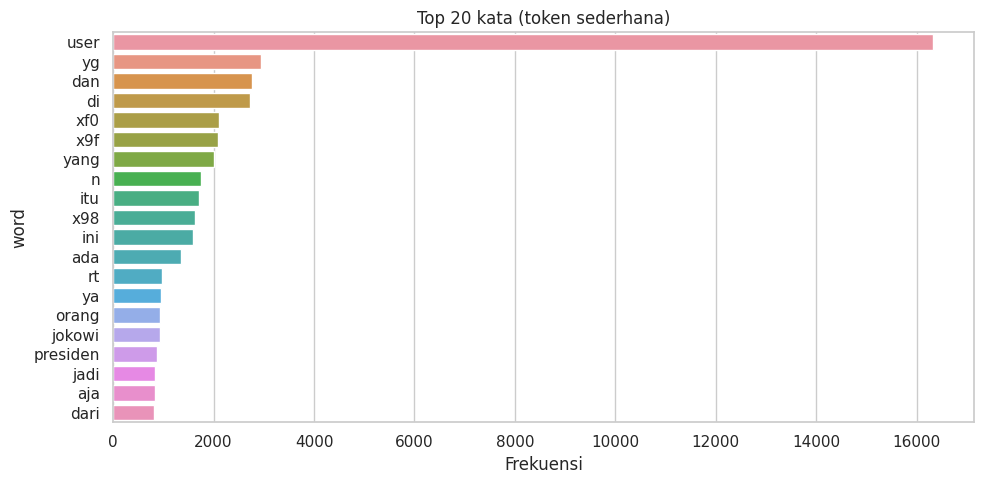

In [7]:
# Quick top tokens (very simple tokenization)
def simple_tokenize(s):
    if pd.isna(s): 
        return []
    s = str(s).lower()
    s = re.sub(r"http\S+|www\S+|https\S+", " ", s)
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    toks = s.split()
    return toks

all_toks = []
sample_texts = df_raw[text_col].fillna("").astype(str)
for t in sample_texts:
    all_toks.extend(simple_tokenize(t))

counter = Counter(all_toks)
top_words = counter.most_common(30)
top_df = pd.DataFrame(top_words, columns=['word','freq'])
display(top_df.head(20))

# Plot top words
plt.figure(figsize=(10,5))
sns.barplot(data=top_df.head(20), x='freq', y='word')
plt.title("Top 20 kata (token sederhana)")
plt.xlabel("Frekuensi")
plt.tight_layout()
plt.show()

## 2. Korelasi Antar Label

Melihat seberapa besar hubungan (korelasi) antar label multilabel. Ini penting untuk memahami apakah beberapa label cenderung muncul bersamaan.


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


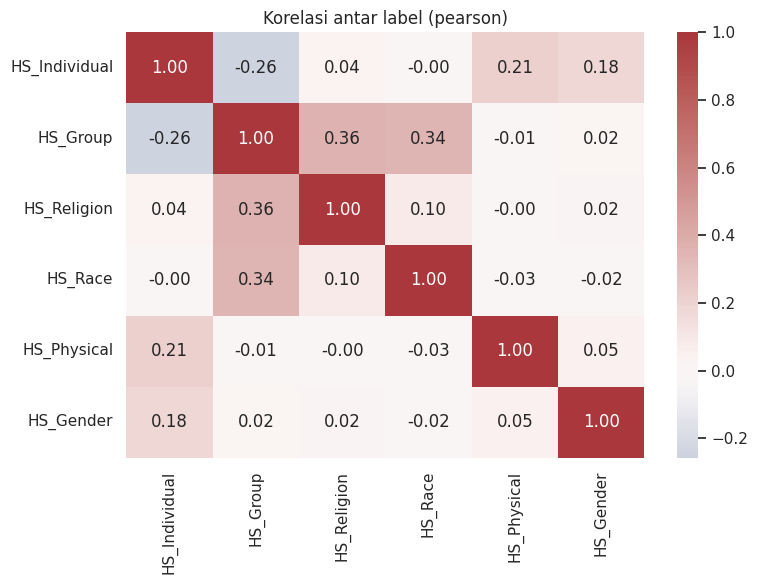

In [8]:
# Korelasi antar label (pearson)
corr = y.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Korelasi antar label (pearson)")
plt.tight_layout()
plt.show()

## 3. Text Preprocessing & Cleaning

Tahap pembersihan teks meliputi:
- **Lowercase** — menyamakan kapitalisasi
- **Hapus URL & Mention** — noise yang tidak relevan
- **Hapus `RT` (retweet)** — artefak Twitter
- **Hapus non-alfabet** — angka, simbol, tanda baca
- **Reduce repeated chars** — misal "keren bangetttt" → "keren bangettt"
- **Normalisasi alay** — memetakan kata alay ke kata baku menggunakan kamus `new_kamusalay.csv`


In [9]:
# === Load kamus alay ===
alay_df = pd.read_csv(ALAY_CSV, encoding='latin-1')
print("Loaded alay mapping:", alay_df.shape)
# Expect columns 'alay' and 'normal' -- jika beda, adjust mapping:
display(alay_df.head(5))

alay_dict = dict(zip(alay_df['alay'].astype(str), alay_df['normal'].astype(str)))

# === Cleaning function ===
RE_URL = re.compile(r"http\S+|www\S+|https\S+")
RE_MENTION = re.compile(r"@\w+")
# RE_NONALPHA = re.compile(r"[^a-zA-Z\s]")   # kita hapus angka/simbol (terserah jika mau dijaga)
RE_MULTISPACE = re.compile(r"\s+")
RE_NONALPHA = re.compile(r"[^a-zA-Z\s]")
def normalize_alay(text):
    tokens = text.split()
    return " ".join([alay_dict.get(t, t) for t in tokens])

def reduce_repeated_chars(text, n=3):
    # reduce characters repeated more than n to n
    return re.sub(r"(.)\1{"+str(n)+",}", r"\1\1\1", text)

def clean_text_pipeline(text, do_alay=True):
    if pd.isna(text): 
        return ""
    s = str(text)
    s = s.lower()
    s = RE_URL.sub(" ", s)
    s = RE_MENTION.sub(" ", s)
    s = s.replace("\\n", " ").replace("\n", " ")
    s = re.sub(r"rt\b", " ", s)   # remove RT
    s = reduce_repeated_chars(s, n=3)
    # optionally preserve emoticons? Here we remove non-alpha
    s = RE_NONALPHA.sub(" ", s)
    s = RE_MULTISPACE.sub(" ", s).strip()
    if do_alay:
        s = normalize_alay(s)
    return s


Loaded alay mapping: (15167, 2)


,alay,normal
0,anakjakartaasikasik,anak jakarta asyik asyik
1,pakcikdahtua,pak cik sudah tua
2,pakcikmudalagi,pak cik muda lagi
3,t3tapjokowi,tetap jokowi
4,3x,tiga kali


### 3.1. Terapkan Pipeline Cleaning ke Seluruh Data

Membersihkan seluruh dataset menggunakan fungsi `clean_text_pipeline` yang sudah didefinisikan. Proses ini mungkin memakan waktu tergantung ukuran dataset.


In [10]:
# Terapkan cleaning (tampilkan progress)
from tqdm import tqdm
tqdm.pandas()

print("Membersihkan teks... ini bisa memakan waktu tergantung dataset size")
df = df_raw.copy()
df['text_before_clean'] = df[text_col].fillna("").astype(str)

# Terapkan cleaning
df['text_clean'] = df['text_before_clean'].progress_apply(lambda x: clean_text_pipeline(x, do_alay=True))

# Kolom tambahan: token count / char len after
df['_len_before'] = df['text_before_clean'].astype(str).apply(len)
df['_len_after']  = df['text_clean'].astype(str).apply(len)

print("\nContoh before / after (random 8):")
sample_idx = df.sample(8, random_state=SEED).index.tolist()
for i, idx in enumerate(sample_idx):
    print(f"\n--- Example {i+1} (index {idx}) ---")
    print("BEFORE:", df.loc[idx,'text_before_clean'][:320])
    print("AFTER :", df.loc[idx,'text_clean'][:320])

Membersihkan teks... ini bisa memakan waktu tergantung dataset size


100%|██████████| 13169/13169 [00:00<00:00, 34502.96it/s]


Contoh before / after (random 8):

--- Example 1 (index 7659) ---
BEFORE: USER aku katakan anjing kpd ahmad dani, boleh....aku katakan babi kpd ahmad dhani, boleh...
AFTER : pengguna aku katakan anjing kepada ahmad dani boleh aku katakan babi kepada ahmad dhani boleh

--- Example 2 (index 3981) ---
BEFORE: USER USER ASTAGA BOLOT BANGET DIA'
AFTER : pengguna pengguna astaga bolot banget dia

--- Example 3 (index 5733) ---
BEFORE: USER Gua emg lagi diving sarap'
AFTER : pengguna gue memang lagi diving sarap

--- Example 4 (index 5292) ---
BEFORE: Mendebat istilah Islam Nusantara nanti saya bisa dituding pro khilafah, HTI, atau ISIS. Sebaliknya mendukung Islam Nusantara saya bisa dicap antek-antek JIL, pro Yahudi, bid'ah dan sesat. Ya sudahlah saya cukup deklarasi bahwa saya orang Indonesia dan be
AFTER : mendebat istilah islam nusantara nanti saya bisa dituding pro khilafah hati atau isis sebaliknya mendukung islam nusantara saya bisa dicap antek antek jil pro yahudi bid ah dan sesat ya

### 3.2. Perbandingan Panjang Teks: Before vs After

Melihat seberapa besar perubahan panjang teks setelah cleaning. Berguna untuk memvalidasi bahwa cleaning tidak menghilangkan terlalu banyak informasi.


,count,mean,std,min,25%,50%,75%,max
_len_before,13169.0,114.202749,69.075620,4.0,59.0,100.0,152.0,561.0
_len_after,13169.0,123.126889,72.015928,4.0,65.0,109.0,167.0,501.0


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


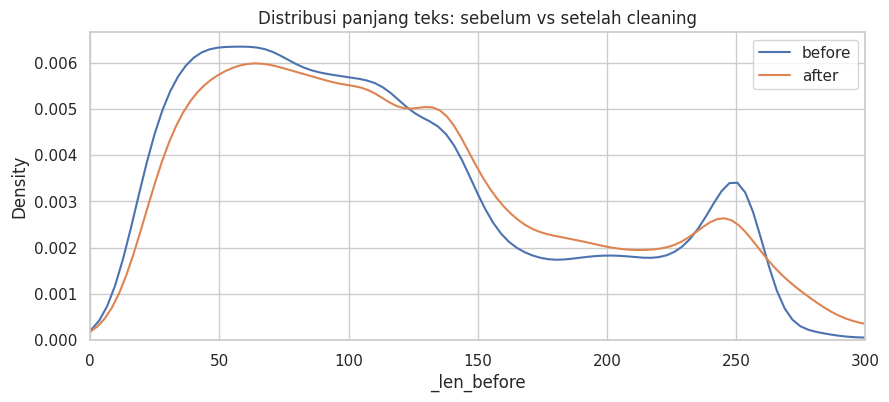

Rata2 penurunan panjang (proporsi): -0.10959488430331403
Persentase teks kosong setelah cleaning: 0.0


In [11]:
# Summary length before/after
display(df[['_len_before','_len_after']].describe().T)

# Plot before/after length distribution (overlay)
plt.figure(figsize=(10,4))
sns.kdeplot(df['_len_before'], label='before', bw_adjust=0.8)
sns.kdeplot(df['_len_after'], label='after', bw_adjust=0.8)
plt.xlim(0, 300)
plt.legend()
plt.title("Distribusi panjang teks: sebelum vs setelah cleaning")
plt.show()

# Ratio perubahan (berapa banyak teks berubah signifikan)
df['len_diff_pct'] = (df['_len_before'] - df['_len_after']) / (df['_len_before'].replace(0,1))
print("Rata2 penurunan panjang (proporsi):", df['len_diff_pct'].mean())
print("Persentase teks kosong setelah cleaning:", (df['text_clean']=="").mean())

## 4. Word Cloud & Visualisasi Teks

Word cloud memberikan gambaran visual tentang kata-kata yang paling dominan muncul di dataset. Stopwords bahasa Indonesia telah ditambahkan untuk memfilter kata-kata umum yang tidak informatif.


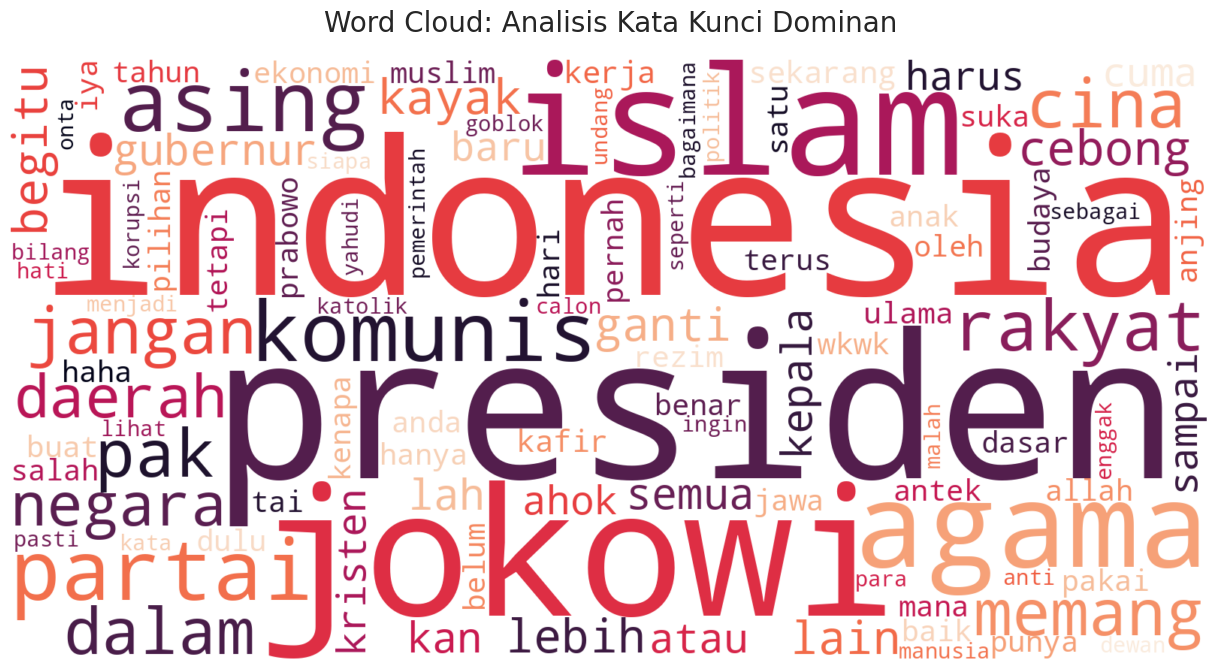

In [12]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# 1. Gabungkan semua teks dari kolom text_clean
all_text = " ".join(text for text in df['text_clean'].astype(str))

# 2. Konsolidasi Semua Stopwords
final_stopwords = set(STOPWORDS)

# Stopwords Bahasa Indonesia & Umum
additional_stopwords = {
    'yang', 'dan', 'di', 'ke', 'dari', 'ini', 'itu', 'yg', 'rt', 'user',
    'url', 'pengguna', 'uniform', 'resource', 'locator', 'aku', 'kamu',
    'dia', 'mereka', 'kita', 'untuk', 'pada', 'adalah', 'dengan', 'karena',
    'bisa', 'jadi', 'kalau', 'saja', 'tidak', 'tapi', 'ya', 'gak', 'nya',
    'masih', 'juga', 'akan', 'sudah', 'apa', 'sih', 'kok', 'banget', 'ada'
}

# Sampah Encoding (Artifacts)
encoding_artifacts = {
    'xf', 'fx', 'xe', 'xa', 'xb', 'xc', 'xd', 'x', 'f'
}

# Cleanup Terakhir (Kata-kata filler/umum)
final_cleanup = {
    'amp', 'saya', 'orang', 'tak', 'bukan', 'ada', 'mau', 
    'banyak', 'bikin', 'tahu', 'tau', 'sih', 'nih', 'gue', 'sama', 'lagi'
}

# Gabungkan semua ke dalam final_stopwords
final_stopwords.update(additional_stopwords)
final_stopwords.update(encoding_artifacts)
final_stopwords.update(final_cleanup)

# 3. Generate WordCloud
wc = WordCloud(
    width=1600,
    height=800,
    background_color='white',
    colormap='rocket',        # Tema bold untuk hate speech/abusive
    max_words=100,            # Fokus pada top 100 kata paling bermakna
    stopwords=final_stopwords,
    min_font_size=10,
    random_state=42,
    collocations=False        # Menghindari pengulangan kata yang sama
).generate(all_text)

# 4. Plotting
plt.figure(figsize=(15, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')  
plt.title('Word Cloud: Analisis Kata Kunci Dominan', fontsize=20, pad=20)

plt.tight_layout(pad=5)
plt.show()

## 5. Analisis Distribusi Label Multilabel

Melihat sebaran setiap label: berapa banyak sampel positif untuk masing-masing kategori, tingkat imbalance, serta rata-rata jumlah label per dokumen.


In [13]:
CLEAN_CSV = os.path.join(OUT_DIR, "clean_data.csv")
df.to_csv(CLEAN_CSV, index=False)
print("Saved clean dataframe to:", CLEAN_CSV)

Saved clean dataframe to: preprocessed_output/clean_data.csv


In [14]:
# Pastikan kolom label masih ada di df; buat y_clean
for c in label_cols:
    if c not in df.columns:
        raise ValueError(f"Label column {c} tidak ditemukan di dataframe")

y_clean = df[label_cols].astype(int)
print("Proporsi label di clean df:")
display(y_clean.mean().sort_values(ascending=False))

# Tambah kolom num_labels (jumlah label positif per sample)
df['num_labels'] = y_clean.sum(axis=1)
print("Distribusi jumlah label per sample:")
display(df['num_labels'].value_counts().sort_index())

Proporsi label di clean df:


HS_Individual    0.271471
HS_Group         0.150809
HS_Religion      0.060217
HS_Race          0.042980
HS_Physical      0.024527
HS_Gender        0.023236
dtype: float64

Distribusi jumlah label per sample:


num_labels
0    7608
1    3740
2    1661
3     153
4       7
Name: count, dtype: int64

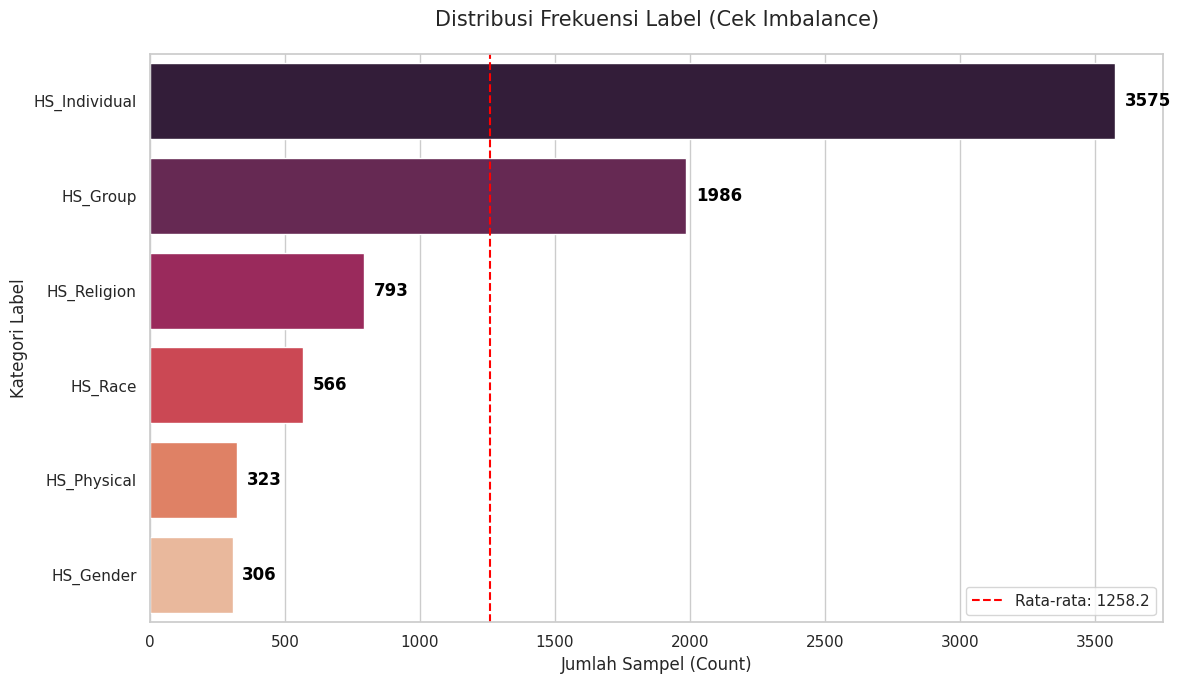

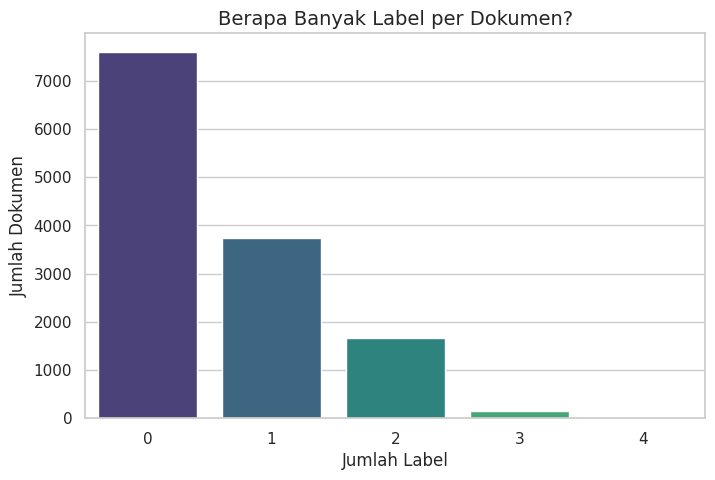

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Hitung total kemunculan tiap label
label_counts = y_clean.sum().sort_values(ascending=False)

# 2. Plotting
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Pakai palette warna 'magma' atau 'rocket' biar kelihatan kontrasnya
ax = sns.barplot(x=label_counts.values, y=label_counts.index, palette='rocket')

# Tambahin angka jumlah di ujung bar biar gak nebak-nebak
for i, v in enumerate(label_counts.values):
    ax.text(v + (max(label_counts.values)*0.01), i, str(int(v)), 
            va='center', fontweight='bold', color='black')

# Tambahin garis rata-rata buat benchmark
avg_count = label_counts.mean()
plt.axvline(avg_count, color='red', linestyle='--', label=f'Rata-rata: {avg_count:.1f}')

plt.title('Distribusi Frekuensi Label (Cek Imbalance)', fontsize=15, pad=20)
plt.xlabel('Jumlah Sampel (Count)', fontsize=12)
plt.ylabel('Kategori Label', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

# 3. Opsional: Plot distribusi jumlah label per baris (num_labels)
plt.figure(figsize=(8, 5))
sns.countplot(x='num_labels', data=df, palette='viridis')
plt.title('Berapa Banyak Label per Dokumen?', fontsize=14)
plt.xlabel('Jumlah Label', fontsize=12)
plt.ylabel('Jumlah Dokumen', fontsize=12)
plt.show()

In [16]:
import pandas as pd

# 1. Hitung total kemunculan tiap label
label_counts = y_clean.sum().sort_values(ascending=False)
total_data = len(y_clean)

# 2. Buat DataFrame Statistik
stats_df = pd.DataFrame({
    'Nama Label': label_counts.index,
    'Jumlah Data (Count)': label_counts.values,
    'Persentase (%)': (label_counts.values / total_data * 100).round(2)
})

# 3. Hitung Imbalance Ratio (Perbandingan terhadap Label Terbanyak)
# Rumus: Count Label Terbanyak / Count Label Saat Ini
max_count = label_counts.max()
stats_df['Imbalance Ratio'] = (max_count / label_counts.values).round(2)

# 4. Tambahkan info tambahan: Berapa data yang tidak punya label sama sekali (Clean/Neutral)
no_label_count = (y_clean.sum(axis=1) == 0).sum()
no_label_pct = (no_label_count / total_data * 100).round(2)

print(f"Total Baris Data: {total_data}")
print(f"Data tanpa label: {no_label_count} ({no_label_pct}%)\n")
print("Tabel Statistik Detail Distribusi Label:")
display(stats_df)

Total Baris Data: 13169
Data tanpa label: 7608 (57.77%)

Tabel Statistik Detail Distribusi Label:


,Nama Label,Jumlah Data (Count),Persentase (%),Imbalance Ratio
0,HS_Individual,3575,27.15,1.00
1,HS_Group,1986,15.08,1.80
2,HS_Religion,793,6.02,4.51
3,HS_Race,566,4.30,6.32
4,HS_Physical,323,2.45,11.07
5,HS_Gender,306,2.32,11.68


## 6. Multilabel Cardinality & Density

Dua metrik penting untuk memahami karakteristik multilabel:
- **Label Cardinality**: rata-rata jumlah label aktif per sampel
- **Label Density**: cardinality dibagi total jumlah label (persentase label aktif rata-rata)


--- Metrik Multilabel ---
Total Sampel      : 13169
Total Kolom Label : 6
Label Cardinality : 0.5732
Label Density     : 0.0955


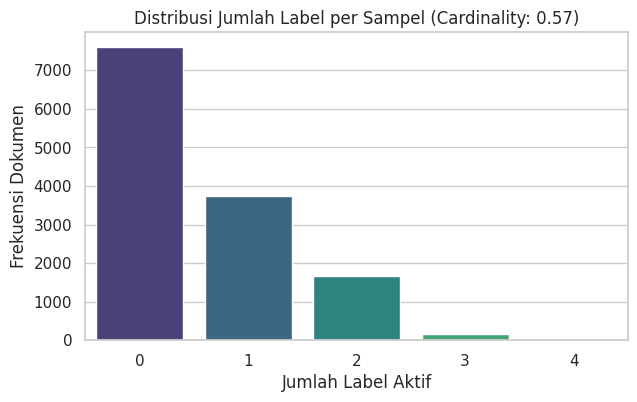

In [17]:
# ======================================================
# Menghitung Metrik Kardinalitas & Density
# ======================================================

total_samples = len(y_clean)
num_labels = y_clean.shape[1]

# 1. Label Cardinality: Rata-rata jumlah label per sampel
# Rumus: (1/N) * sum(jumlah label tiap baris)
cardinality = y_clean.sum(axis=1).mean()

# 2. Label Density: Kardinalitas dibagi jumlah total kategori label yang ada
# Ini menunjukkan persentase label yang aktif rata-rata per sampel
density = cardinality / num_labels

print(f"--- Metrik Multilabel ---")
print(f"Total Sampel      : {total_samples}")
print(f"Total Kolom Label : {num_labels}")
print(f"Label Cardinality : {cardinality:.4f}")
print(f"Label Density     : {density:.4f}")

# Visualisasi distribusi jumlah label (Lagi, untuk konteks kardinalitas)
plt.figure(figsize=(7, 4))
sns.countplot(x=y_clean.sum(axis=1), palette='viridis')
plt.title(f'Distribusi Jumlah Label per Sampel (Cardinality: {cardinality:.2f})')
plt.xlabel('Jumlah Label Aktif')
plt.ylabel('Frekuensi Dokumen')
plt.show()

## 7. Stratified Train-Test Split (Multilabel)

Membagi dataset menjadi train (80%) dan test (20%) menggunakan **MultilabelStratifiedShuffleSplit** agar proporsi label tetap terjaga di kedua split.


In [18]:
# ======================================================
# Multilabel Stratified Split
# ======================================================
test_size = 0.2   # adjust jika perlu
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=SEED)

X = df['text_clean']
Y = y_clean.reset_index(drop=True)

for tr_idx, te_idx in msss.split(X, Y):
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    test_df  = df.iloc[te_idx].reset_index(drop=True)

print("Train size:", len(train_df))
print("Test size :", len(test_df))

# Periksa proporsi label di masing2 split
print("\nProporsi label (train):")
display(train_df[label_cols].mean().sort_values(ascending=False))
print("\nProporsi label (test):")
display(test_df[label_cols].mean().sort_values(ascending=False))

Train size: 10535
Test size : 2634

Proporsi label (train):


HS_Individual    0.271476
HS_Group         0.150831
HS_Religion      0.060180
HS_Race          0.043000
HS_Physical      0.024490
HS_Gender        0.023256
dtype: float64


Proporsi label (test):


HS_Individual    0.271450
HS_Group         0.150721
HS_Religion      0.060364
HS_Race          0.042901
HS_Physical      0.024677
HS_Gender        0.023159
dtype: float64

In [19]:
TRAIN_CSV = os.path.join(OUT_DIR, "train_df.csv")
TEST_CSV  = os.path.join(OUT_DIR, "test_df.csv")

train_df.to_csv(TRAIN_CSV, index=False)
test_df.to_csv(TEST_CSV, index=False)
print("Saved train ->", TRAIN_CSV)
print("Saved test  ->", TEST_CSV)

Saved train -> preprocessed_output/train_df.csv
Saved test  -> preprocessed_output/test_df.csv


## 8. Sampel untuk Dokumentasi Laporan

Mengambil sampel acak dari test set untuk ditampilkan di Bab 4 laporan skripsi (contoh before/after cleaning beserta label).


In [20]:
# Ambil sample untuk Bab 4: before/after + labels
n_show = 8
sample_for_report = test_df.sample(n_show, random_state=15)[[
    'text_before_clean', 'text_clean'] + label_cols + ['num_labels']
]
display(sample_for_report)
# Save sample report
sample_for_report.to_csv(os.path.join(OUT_DIR, "sample_before_after.csv"), index=False)
print("Saved sample_before_after.csv")

,text_before_clean,text_clean,HS_Individual,HS_Group,HS_Religion,HS_Race,HS_Physical,HS_Gender,num_labels
1990,RT USER: Prabowo akan selalu dimusuhi PKI dan ...,pengguna prabowo akan selalu dimusuhi partai k...,1,0,0,0,0,0,1
2369,USER USER KIRAIN BUDEK',pengguna pengguna kiraan budek,0,0,0,0,0,0,0
193,USER USER USER USER USER &lt;strong&gt;DASAR C...,pengguna pengguna pengguna pengguna pengguna l...,0,1,0,0,0,0,1
881,Kampret. Datang pas butuh aja. Ngerusak mood s...,kampret datang pas butuh saja merusak suasana ...,1,0,0,0,0,0,1
843,USER Kenapa? Terguncang ente mendengarnya pak?...,pengguna kenapa terguncang kamu mendengarnya p...,0,0,0,0,0,0,0
1491,USER USER USER Yang yahudi juga',pengguna pengguna pengguna yang yahudi juga,0,0,0,0,0,0,0
1362,USER USER USER USER Emang ga bisa kasis refere...,pengguna pengguna pengguna pengguna memang tid...,0,0,0,0,0,0,0
1273,USER USER USER USER USER USER USER USER USER U...,pengguna pengguna pengguna pengguna pengguna p...,0,0,0,0,0,0,0


Saved sample_before_after.csv


<Figure size 1000x400 with 0 Axes>

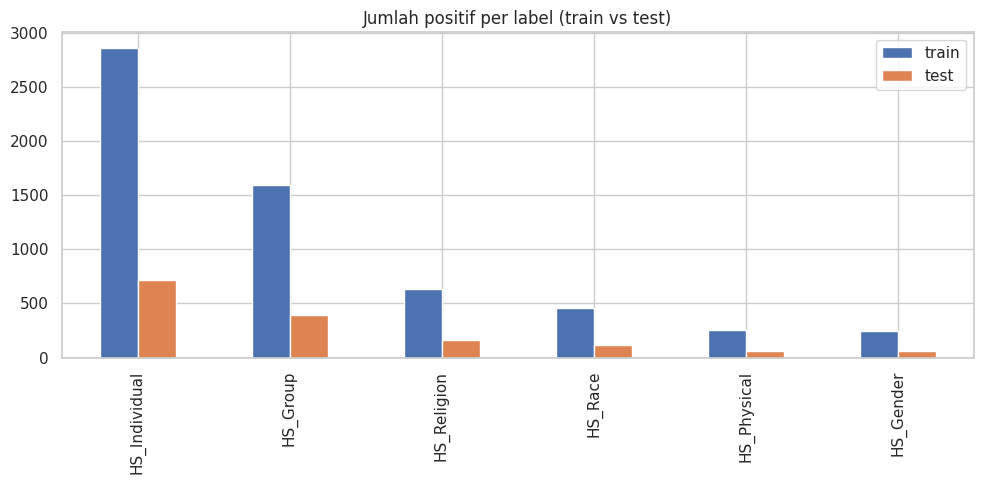

In [21]:
# Label counts
train_counts = train_df[label_cols].sum().sort_values(ascending=False)
test_counts  = test_df[label_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10,4))
pd.DataFrame({'train': train_counts, 'test': test_counts}).plot.bar()
plt.title("Jumlah positif per label (train vs test)")
plt.tight_layout()
plt.show()

## 9. Simpan Output & Ringkasan

Menyimpan seluruh output preprocessing: data clean, train/test CSV, sample before/after, dan ringkasan JSON untuk referensi ke depannya.


In [22]:
import json
summary = {
    "raw_shape": df_raw.shape,
    "clean_shape": df.shape,
    "train_size": len(train_df),
    "test_size": len(test_df),
    "label_props_raw": df_raw[label_cols].mean().to_dict(),
    "label_props_clean": df[label_cols].mean().to_dict(),
    "seed": SEED
}
with open(os.path.join(OUT_DIR,"preprocess_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)
print("Saved preprocess_summary.json")

Saved preprocess_summary.json
